In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader,random_split

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [3]:
train_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


In [4]:

train_size = int(0.9 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

In [5]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28*28, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)          # (batch, 1, 28, 28) -> (batch, 784)
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.fc3(x)              # raw logits, no softmax here
        return x

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ANN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
def evaluate(loader):
    model.eval()                     # disables dropout, freezes BN running stats
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():            # no gradient tracking needed for eval -> saves memory/compute
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


num_epochs = 17
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()                    # enables dropout, lets BN use batch stats
    running_loss = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()        # clear old gradients
        outputs = model(images)      # forward pass
        loss = criterion(outputs, labels)
        loss.backward()              # backprop: compute gradients
        optimizer.step()             # update weights

        running_loss += loss.item() * images.size(0)
        total += images.size(0)

    train_loss = running_loss / total
    train_loss_eval, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/17 | Train Loss: 0.3444 | Val Loss: 0.1263 | Val Acc: 0.9637
Epoch 2/17 | Train Loss: 0.1541 | Val Loss: 0.0934 | Val Acc: 0.9715
Epoch 3/17 | Train Loss: 0.1190 | Val Loss: 0.0752 | Val Acc: 0.9768
Epoch 4/17 | Train Loss: 0.0993 | Val Loss: 0.0743 | Val Acc: 0.9768
Epoch 5/17 | Train Loss: 0.0890 | Val Loss: 0.0666 | Val Acc: 0.9805
Epoch 6/17 | Train Loss: 0.0790 | Val Loss: 0.0623 | Val Acc: 0.9810
Epoch 7/17 | Train Loss: 0.0738 | Val Loss: 0.0593 | Val Acc: 0.9812
Epoch 8/17 | Train Loss: 0.0649 | Val Loss: 0.0563 | Val Acc: 0.9817
Epoch 9/17 | Train Loss: 0.0607 | Val Loss: 0.0630 | Val Acc: 0.9820
Epoch 10/17 | Train Loss: 0.0578 | Val Loss: 0.0545 | Val Acc: 0.9842
Epoch 11/17 | Train Loss: 0.0505 | Val Loss: 0.0553 | Val Acc: 0.9833
Epoch 12/17 | Train Loss: 0.0488 | Val Loss: 0.0555 | Val Acc: 0.9823
Epoch 13/17 | Train Loss: 0.0469 | Val Loss: 0.0563 | Val Acc: 0.9832
Epoch 14/17 | Train Loss: 0.0454 | Val Loss: 0.0555 | Val Acc: 0.9848
Epoch 15/17 | Train Loss: 0.0

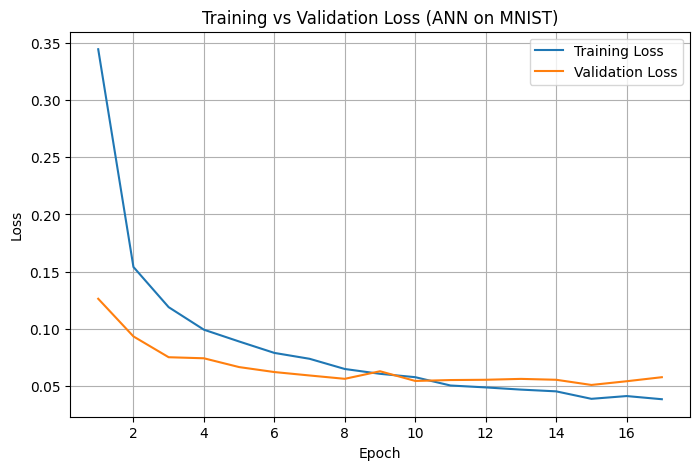

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (ANN on MNIST)')
plt.legend()
plt.grid(True)
plt.savefig('ann_loss_curve.png')
plt.show()

In [10]:
test_loss, test_acc = evaluate(test_loader)
print(f"Final Test Accuracy (ANN): {test_acc*100:.2f}%")

Final Test Accuracy (ANN): 98.18%


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Flatten MNIST tensors into (N, 784) numpy arrays for sklearn
X_train = train_full.data.numpy().reshape(len(train_full), -1) / 255.0
y_train = train_full.targets.numpy()
X_test = test_dataset.data.numpy().reshape(len(test_dataset), -1) / 255.0
y_test = test_dataset.targets.numpy()

log_reg = LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs')
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
